Generating probabilities and animations for 2 drones...
Generating animation for 2 drones at 100% overlap...
Generating animation for 2 drones at 50% overlap...
Generating animation for 2 drones at 10% overlap...
Saving combined GIF for 2 drones at all overlap levels...
Saved combined animation for 2 drones: combined_drone_sim_2drones.gif
Generating probabilities and animations for 3 drones...
Generating animation for 3 drones at 100% overlap...
Generating animation for 3 drones at 50% overlap...
Generating animation for 3 drones at 10% overlap...
Saving combined GIF for 3 drones at all overlap levels...
Saved combined animation for 3 drones: combined_drone_sim_3drones.gif
Generating probabilities and animations for 4 drones...
Generating animation for 4 drones at 100% overlap...
Generating animation for 4 drones at 50% overlap...
Generating animation for 4 drones at 10% overlap...
Saving combined GIF for 4 drones at all overlap levels...
Saved combined animation for 4 drones: combined

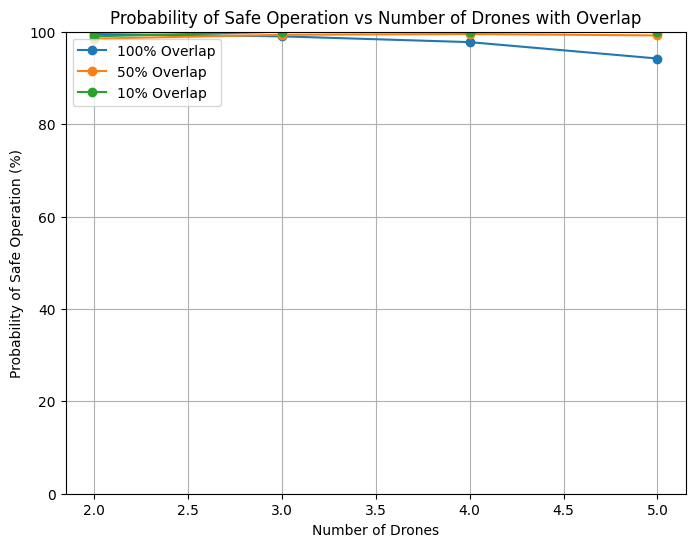

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Function to compute total simulation area based on overlap
def compute_total_area(num_drones, base_size, overlap_percentage):
    """Compute the required total area size based on overlap percentage."""
    if overlap_percentage == 100:
        return base_size, base_size

    step_size = base_size * (1 - overlap_percentage / 100)
    total_width = step_size * (num_drones - 1) + base_size
    return total_width, base_size

# Function to initialize drone positions
def initialize_positions(num_drones, base_size, height_limit, overlap_percentage, random_seed):
    np.random.seed(random_seed)
    if overlap_percentage == 100:
        return np.random.rand(num_drones, 3) * [base_size, base_size, height_limit]

    positions = np.zeros((num_drones, 3))
    start_x = 0
    for i in range(num_drones):
        x_min, x_max = start_x, start_x + base_size
        positions[i] = [
            np.random.uniform(x_min, x_max),
            np.random.uniform(0, base_size),
            np.random.uniform(0, height_limit)
        ]
        start_x += base_size * (1 - overlap_percentage / 100)
    return positions

# Function to simulate drone movements
def simulate_one_time(area_width, area_height, min_safe_distance, num_drones, num_frames, height_limit, drone_speed,
                      reaction_distance, avoidance_probability, overlap_percentage, random_seed=None):
    np.random.seed(random_seed)
    positions = initialize_positions(num_drones, 1000, height_limit, overlap_percentage, random_seed)
    directions = np.random.rand(num_drones, 3) - 0.5
    directions /= np.linalg.norm(directions, axis=1)[:, np.newaxis]
    velocities = directions * drone_speed
    operational_status = np.ones(num_drones, dtype=bool)
    total_collisions = 0
    trajectory = [positions.copy()]

    for frame in range(num_frames):
        for i in range(num_drones):
            if not operational_status[i]:
                continue

            new_position = positions[i] + velocities[i]
            for dim in range(3):
                if new_position[dim] < 0 or new_position[dim] > [area_width, area_height, height_limit][dim]:
                    velocities[i, dim] *= -1
                    new_position = positions[i] + velocities[i]
            positions[i] = new_position

        for i in range(num_drones):
            if not operational_status[i]:
                continue
            for j in range(i + 1, num_drones):
                if not operational_status[j]:
                    continue
                distance = np.linalg.norm(positions[i] - positions[j])
                if distance < min_safe_distance:
                    if distance < reaction_distance and np.random.rand() < avoidance_probability:
                        new_direction = np.random.rand(3) - 0.5
                        new_direction /= np.linalg.norm(new_direction)
                        velocities[i] = new_direction * drone_speed
                        velocities[j] = -new_direction * drone_speed
                    else:
                        operational_status[i] = operational_status[j] = False
                        total_collisions += 1
        trajectory.append(positions.copy())
    return trajectory, total_collisions

# Function to generate animation with blue borders and titles
def generate_animation(frames, num_drones, area_width, area_height, min_safe_distance, overlap_percentage):
    scale = 500 / 1000  # Keep size constant for each 1000m x 1000m area
    images = []

    # Titles based on overlap percentage
    titles = {100: "100% Overlap", 50: "50% Overlap", 10: "10% Overlap"}
    title_text = titles.get(overlap_percentage, f"{overlap_percentage}% Overlap")

    for positions in frames:
        img_width = int(area_width * scale)
        img_height = 550  # Increased to make space for the title
        img = Image.new("RGB", (img_width, img_height), "white")
        draw = ImageDraw.Draw(img)

        # Add title text
        font = ImageFont.truetype("arial.ttf", 30)
        text_width = draw.textbbox((0, 0), title_text, font=font)[2]
        draw.text(((img_width - text_width) // 2, 10), title_text, fill="black", font=font)

        # Draw blue borders for each 1000m x 1000m flight volume
        start_x = 0
        for _ in range(num_drones):
            x1, y1 = start_x * scale, 50  # Start below the title
            x2, y2 = (start_x + 1000) * scale, 550
            draw.rectangle([x1, y1, x2, y2], outline="blue", width=3)
            start_x += 1000 * (1 - overlap_percentage / 100)

        # Draw drones and safety bubbles
        for pos in positions:
            x, y = pos[0] * scale, pos[1] * scale + 50  # Offset for title
            draw.ellipse([x-60*scale, y-60*scale, x+60*scale, y+60*scale], outline="gray", width=1)  # Safety bubble
            draw.ellipse([x-5, y-5, x+5, y+5], fill="red", outline="black")  # Drone

        images.append(img)
    return images

# Function to combine GIFs side by side with spacing
def combine_gifs(gif_sets, output_filename):
    frame_height = 550  # Increased to fit titles
    spacing = 20  # Add spacing between simulations
    max_width = sum(gif[0].width for gif in gif_sets.values()) + (spacing * (len(gif_sets) - 1))

    combined_images = []
    for frame_idx in range(len(gif_sets[100])):  # Assume all have the same frame count
        combined_img = Image.new("RGB", (max_width, frame_height), "white")

        x_offset = 0
        for overlap in [100, 50, 10]:
            gif_frame = gif_sets[overlap][frame_idx]
            combined_img.paste(gif_frame, (x_offset, 0))
            x_offset += gif_frame.width + spacing  # Move to the right with spacing

        combined_images.append(combined_img)

    combined_images[0].save(output_filename, save_all=True, append_images=combined_images[1:], duration=100, loop=0)

# Function to simulate 100 times and return the probability of safe operation
def simulate_multiple_times(area_width, area_height, min_safe_distance, num_drones, num_frames, height_limit, drone_speed,
                            reaction_distance, avoidance_probability, overlap_percentage, num_simulations=100, random_seed=None):
    np.random.seed(random_seed)
    all_probabilities = []

    for _ in range(num_simulations):
        trajectory, total_collisions = simulate_one_time(area_width, area_height, min_safe_distance, num_drones, num_frames,
                                                         height_limit, drone_speed, reaction_distance, avoidance_probability,
                                                         overlap_percentage, random_seed)

        # Calculate safety probability for the current run
        safe_operation_prob = (1 - total_collisions / num_drones) * 100  # Assuming collision count over drones gives the safety prob
        all_probabilities.append(safe_operation_prob)

    # Calculate average safety probability over all simulations
    avg_safe_prob = np.mean(all_probabilities)
    return avg_safe_prob

# Run simulations for multiple runs (100 simulations) but generate a single GIF per overlap level
drone_counts = [2, 3, 4, 5]
overlap_levels = [100, 50, 10]
results = {overlap: [] for overlap in overlap_levels}  # Initialize empty lists for each overlap level

# Initialize gif_sets dictionary outside the loop for combination later
gif_sets = {overlap: [] for overlap in overlap_levels}

# Generate combined GIFs for each number of drones
for num_drones in drone_counts:
    print(f"Generating probabilities and animations for {num_drones} drones...")
    
    # Initialize gif_sets dictionary for the current number of drones
    gif_sets = {overlap: [] for overlap in overlap_levels}
    
    # Create a list to store the filenames for the combined GIFs
    gif_filenames = []

    for overlap in overlap_levels:
        try:
            # Run 100 simulations and calculate the average safety probability
            area_width, area_height = compute_total_area(num_drones, 1000, overlap)
            avg_safe_prob = simulate_multiple_times(area_width, area_height, 60, num_drones, 30, 60, 10, 200, 0.8, overlap, num_simulations=100)
            
            # Store the result for plotting
            results[overlap].append(avg_safe_prob)
            
            # For GIF generation, simulate just once (since you only need one for visualization)
            trajectory, _ = simulate_one_time(area_width, area_height, 60, num_drones, 30, 60, 10, 200, 0.8, overlap)
            
            # Generate animation for this simulation
            print(f"Generating animation for {num_drones} drones at {overlap}% overlap...")
            gif_sets[overlap] = generate_animation(trajectory, num_drones, area_width, area_height, 60, overlap)
            
            # Save GIF for this overlap level
            output_filename = f"drone_sim_{num_drones}drones_{overlap}percent_overlap.gif"
            gif_filenames.append(output_filename)  # Add the output filename to the list
            
        except Exception as e:
            print(f"Error generating GIF for {num_drones} drones at {overlap}% overlap: {e}")
            continue

    # Check if all GIF sets for the current drone count are populated
    if all(len(gif_sets[overlap]) > 0 for overlap in overlap_levels):
        # Combine the GIFs into one combined animation
        print(f"Saving combined GIF for {num_drones} drones at all overlap levels...")
        try:
            combine_gifs(gif_sets, f"combined_drone_sim_{num_drones}drones.gif")
            print(f"Saved combined animation for {num_drones} drones: combined_drone_sim_{num_drones}drones.gif")
        except Exception as e:
            print(f"Error combining GIFs for {num_drones} drones: {e}")
    else:
        print(f"Skipping combined GIF creation for {num_drones} drones due to missing animations.")

# Plot the results for safety probabilities
plt.figure(figsize=(8, 6))

# Loop over overlap levels and plot each set of probabilities
for overlap, probabilities in results.items():
    plt.plot(drone_counts, probabilities, marker='o', linestyle='-', label=f'{overlap}% Overlap')

# Add labels and adjust y-axis from 0 to 100
plt.ylim(0, 100)
plt.title("Probability of Safe Operation vs Number of Drones with Overlap")
plt.xlabel("Number of Drones")
plt.ylabel("Probability of Safe Operation (%)")
plt.legend()  # Add legend
plt.grid(True)
plt.show()

